In [5]:
import pandas as pd
import numpy as np
import os


from matplotlib import pyplot as plt
import sklearn.ensemble

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc

from xailib.data_loaders.dataframe_loader import prepare_dataframe


from xailib.explainers.lore_explainer import LoreTabularExplainer
from xailib.explainers.shap_explainer_tab import ShapXAITabularExplainer

from xailib.models.sklearn_classifier_wrapper import sklearn_classifier_wrapper

In [4]:
path = os.getcwd()
print(path)

/Users/eleonoracappuccio/xai-visualization_rules_fi/notebooks/experiments_dataset+anchor


In [7]:
source_file=f'../../datasets/titanic_c.csv'

In [8]:
df=pd.read_csv(source_file)
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
5,0,3,1,28.0,0,0,8.4583,1
6,0,1,1,54.0,0,0,51.8625,2
7,0,3,1,2.0,3,1,21.0750,2
8,1,3,0,27.0,0,2,11.1333,2
9,1,2,0,14.0,1,0,30.0708,0


In [9]:
print(df.groupby('Survived').size())

Survived
0    549
1    342
dtype: int64


In [10]:
class_field='Survived'

In [11]:
df, feature_names, class_values, numeric_columns, rdf, real_feature_names, features_map = prepare_dataframe(df, class_field)

In [12]:
X = df.drop('Survived', axis=1)  # Features (all columns except 'Survived')
y = df['Survived']

In [13]:
test_size = 0.4
random_state = 4
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                        test_size=test_size,
                                                        random_state=random_state,
                                                        stratify=y)

### Train a Logistic Regression

In [14]:
model_LR= LogisticRegression()

In [15]:
model_LR.fit(X_train, y_train)

LogisticRegression()

In [22]:
bbox = sklearn_classifier_wrapper(model_LR)

In [16]:
y_prob = model_LR.predict_proba(X_test)[:,1] # This will give you positive class prediction probabilities  
y_pred = np.where(y_prob > 0.5, 1, 0) # This will threshold the probabilities to give class predictions.
model_LR.score(X_test, y_pred)

1.0

In [17]:
confusion_matrix=metrics.confusion_matrix(y_test,y_pred)
confusion_matrix

array([[177,  43],
       [ 41,  96]])

In [18]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

0.8205374917053749

Text(0.5, 0, 'False Positive Rate')

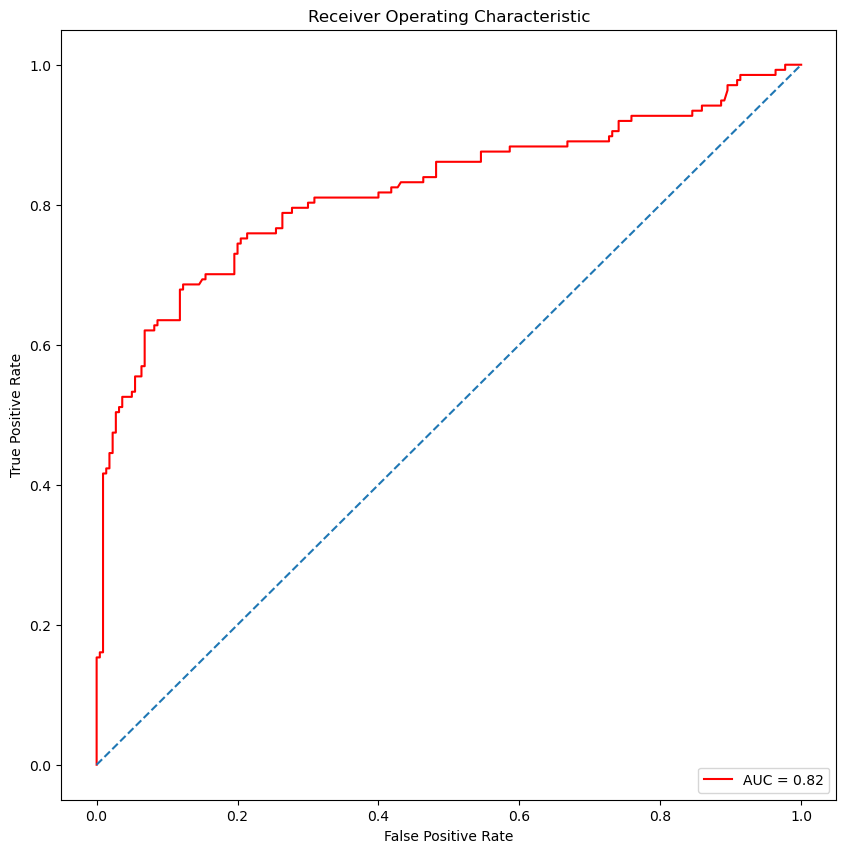

In [19]:
%matplotlib inline
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

### LORE

In [23]:
r=list(range(0,6))
for i in r:
    inst = X_train.iloc[i].values
    print('Instance ',inst)
    print('True class ',y_train.iloc[6])
    print('Predicted class ',model_LR.predict(inst.reshape(1, -1)))
    explainer = LoreTabularExplainer(bbox)
    config = {'neigh_type':'geneticp', 'size':1000, 'ocr':0.1, 'ngen':10}
    explainer.fit(df, class_field, config)

    exp = explainer.explain(inst)
    print(exp)
    exp.expDict

Instance  [ 1.   1.  55.   0.   0.  30.5  2. ]
True class  0
Predicted class  [0]
Instance  [ 2.   1.  24.   2.   0.  73.5  2. ]
True class  0
Predicted class  [0]
Instance  [ 2.    0.   28.    0.    0.   12.65  2.  ]
True class  0
Predicted class  [1]
Instance  [ 3.   1.  18.   0.   0.   8.3  2. ]
True class  0
Predicted class  [0]
Instance  [ 3.    1.   28.    0.    0.    7.75  1.  ]
True class  0
Predicted class  [0]
Instance  [ 3.     1.    28.     0.     0.    22.525  2.   ]
True class  0
Predicted class  [0]


In [24]:
exp.plotRules()